In [2]:
# 1:Upload Your Dataset
from google.colab import files
uploaded = files.upload()


Saving zomato_data.csv to zomato_data (1).csv


In [3]:
#STEP 2: Import Libraries
import pandas as pd
import numpy as np

In [4]:
#STEP 3: Load Dataset
df = pd.read_csv('zomato_data.csv')

In [6]:
#STEP 4: View Data (VERY IMPORTANT)
df.head()
#👉 This shows first 5 rows

,Order_ID,Customer_ID,Customer_Name,City,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,Order_Time,Delivery_Time_mins,Order_Amount,Discount,Final_Amount,Payment_Mode,Rating,Delivery_Partner_ID,Order_Status
0,1001,C001,Rahul Sharma,Bengaluru,R101,Spice Garden,North Indian,2026-01-05,12:30,35,450,50,400,UPI,4.5,DP001,Delivered
1,1002,C002,Priya Patel,Mumbai,R102,The Biryani House,Biryani,2026-01-05,13:00,42,620,0,620,Credit Card,4.8,DP002,Delivered
2,1003,C003,Amit Kumar,Delhi,R103,Pizza Palace,Pizza,2026-01-05,19:45,28,380,30,350,Debit Card,4.2,DP003,Delivered
3,1004,C004,Sneha Reddy,Hyderabad,R104,Andhra Spice,South Indian,2026-01-06,08:15,20,290,0,290,Cash,4.6,DP004,Delivered
4,1005,C005,Vikram Singh,Pune,R105,Punjabi Tadka,North Indian,2026-01-06,12:00,33,510,60,450,UPI,4.3,DP005,Delivered


In [8]:
#STEP 5: Check Column Names (MOST IMPORTANT STEP)
print(df.columns)

#👉  This step solves your error
#👉 Your column names may NOT be:

#"Restaurant Name"
#"Location"

Index(['Order_ID', 'Customer_ID', 'Customer_Name', 'City', 'Restaurant_ID',
       'Restaurant_Name', 'Cuisine_Type', 'Order_Date', 'Order_Time',
       'Delivery_Time_mins', 'Order_Amount', 'Discount', 'Final_Amount',
       'Payment_Mode', 'Rating', 'Delivery_Partner_ID', 'Order_Status'],
      dtype='object')


In [10]:
#STEP 6: Clean Column Names (Fix Errors Forever)
df.columns = df.columns.str.strip()   # remove spaces
df.columns = df.columns.str.lower()   # lowercase

print(df.columns)

#👉 Example output:
#['name', 'city', 'rating', 'cost', 'cuisine']

Index(['order_id', 'customer_id', 'customer_name', 'city', 'restaurant_id',
       'restaurant_name', 'cuisine_type', 'order_date', 'order_time',
       'delivery_time_mins', 'order_amount', 'discount', 'final_amount',
       'payment_mode', 'rating', 'delivery_partner_id', 'order_status'],
      dtype='object')


In [11]:
#STEP 7: Basic Info About Data
df.columns = df.columns.str.strip()   # remove spaces
df.columns = df.columns.str.lower()   # lowercase

print(df.columns)


#👉 Example output:
#['name', 'city', 'rating', 'cost', 'cuisine']

Index(['order_id', 'customer_id', 'customer_name', 'city', 'restaurant_id',
       'restaurant_name', 'cuisine_type', 'order_date', 'order_time',
       'delivery_time_mins', 'order_amount', 'discount', 'final_amount',
       'payment_mode', 'rating', 'delivery_partner_id', 'order_status'],
      dtype='object')


In [23]:
print(df.columns)

Index(['order_id', 'customer_id', 'customer_name', 'city', 'restaurant_id',
       'restaurant_name', 'cuisine_type', 'order_date', 'order_time',
       'delivery_time_mins', 'order_amount', 'discount', 'final_amount',
       'payment_mode', 'rating', 'delivery_partner_id', 'order_status'],
      dtype='object')


In [12]:
#STEP 8: Basic Info About Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             50 non-null     int64  
 1   customer_id          50 non-null     object 
 2   customer_name        50 non-null     object 
 3   city                 50 non-null     object 
 4   restaurant_id        50 non-null     object 
 5   restaurant_name      50 non-null     object 
 6   cuisine_type         50 non-null     object 
 7   order_date           50 non-null     object 
 8   order_time           50 non-null     object 
 9   delivery_time_mins   50 non-null     int64  
 10  order_amount         50 non-null     int64  
 11  discount             50 non-null     int64  
 12  final_amount         50 non-null     int64  
 13  payment_mode         50 non-null     object 
 14  rating               50 non-null     float64
 15  delivery_partner_id  50 non-null     objec

In [13]:
#STEP 9: Handle Missing Values (SAFE METHOD)
# Check missing values
print(df.isnull().sum())

order_id               0
customer_id            0
customer_name          0
city                   0
restaurant_id          0
restaurant_name        0
cuisine_type           0
order_date             0
order_time             0
delivery_time_mins     0
order_amount           0
discount               0
final_amount           0
payment_mode           0
rating                 0
delivery_partner_id    0
order_status           0
dtype: int64


In [14]:
#Fill missing ratings (if exists)
if 'rating' in df.columns:
    df['rating'] = df['rating'].fillna(df['rating'].mean())

In [15]:
#STEP 10: Remove Duplicates
df = df.drop_duplicates()

In [16]:
#STEP 11: Fix Data Types
# Convert rating to numeric
if 'rating' in df.columns:
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [17]:
#STEP 12: Simple EDA (Start Easy)
if 'rating' in df.columns:
    top_restaurants = df.sort_values(by='rating', ascending=False).head(10)
    print(top_restaurants)

    order_id customer_id   customer_name       city restaurant_id  \
42      1043        C004     Sneha Reddy  Hyderabad          R120   
18      1019        C013  Lakshmi Pillai  Bengaluru          R108   
25      1026        C011   Divya Nambiar  Hyderabad          R120   
33      1034        C019  Sunita Agarwal  Hyderabad          R120   
7       1008        C007      Arjun Nair  Bengaluru          R108   
46      1047        C023   Preethi Kumar  Bengaluru          R108   
16      1017        C006      Meena Iyer    Chennai          R115   
31      1032        C001    Rahul Sharma  Bengaluru          R108   
34      1035        C016   Ravi Krishnan    Chennai          R115   
47      1048        C022     Nandini Rao    Chennai          R115   

    restaurant_name  cuisine_type  order_date order_time  delivery_time_mins  \
42   Hyderabadi Dum       Biryani  2026-01-19      13:00                  36   
18       Sushi Stop      Japanese  2026-01-11      19:45                  48   


In [18]:
#🍜 Popular Cuisines
if 'cuisines' in df.columns:
    print(df['cuisines'].value_counts().head(10))

In [20]:
#Orders by City
if 'city' in df.columns:
    print(df['city'].value_counts().head(10))

city
Bengaluru    15
Mumbai        8
Hyderabad     6
Chennai       6
Pune          6
Delhi         5
Kolkata       4
Name: count, dtype: int64


In [21]:
#STEP 13: Visualization (VERY SIMPLE)
import matplotlib.pyplot as plt

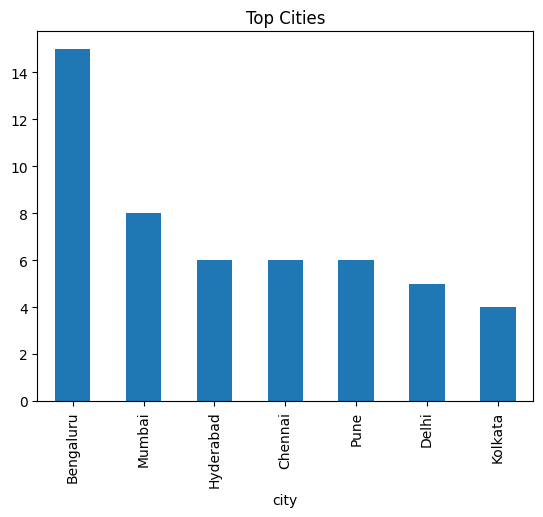

In [22]:
#Top Cities
if 'city' in df.columns:
    df['city'].value_counts().head(10).plot(kind='bar')
    plt.title("Top Cities")
    plt.show()